In [1]:
#importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

In [2]:
#reading our data set
df = pd.read_csv('../data/ufo_sightings_scrubbed.csv')

#checking first 10 outputs of dataframe
df.head(10)

C:\Users\foxyh\AppData\Local\Temp\ipykernel_34696\2521318126.py:2: DtypeWarning: Columns (5,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/ufo_sightings_scrubbed.csv')


,datetime,city,state,country,shape,duration (seconds),duration (hours/min),comments,date posted,latitude,longitude
0,1949-10-10 20:30:00,san marcos,tx,us,cylinder,2700,45 minutes,This event took place in early fall around 194...,2004-04-27,29.8830556,-97.941111
1,1949-10-10 21:00:00,lackland afb,tx,NaN,light,7200,1-2 hrs,1949 Lackland AFB&#44 TX. Lights racing acros...,2005-12-16,29.38421,-98.581082
2,1955-10-10 17:00:00,chester (uk/england),NaN,gb,circle,20,20 seconds,Green/Orange circular disc over Chester&#44 En...,2008-01-21,53.2,-2.916667
3,1956-10-10 21:00:00,edna,tx,us,circle,20,1/2 hour,My older brother and twin sister were leaving ...,2004-01-17,28.9783333,-96.645833
4,1960-10-10 20:00:00,kaneohe,hi,us,light,900,15 minutes,AS a Marine 1st Lt. flying an FJ4B fighter/att...,2004-01-22,21.4180556,-157.803611
5,1961-10-10 19:00:00,bristol,tn,us,sphere,300,5 minutes,My father is now 89 my brother 52 the girl wit...,2007-04-27,36.595,-82.188889
6,1965-10-10 21:00:00,penarth (uk/wales),NaN,gb,circle,180,about 3 mins,penarth uk circle 3mins stayed 30ft above m...,2006-02-14,51.434722,-3.180000
7,1965-10-10 23:45:00,norwalk,ct,us,disk,1200,20 minutes,A bright orange color changing to reddish colo...,1999-10-02,41.1175,-73.408333
8,1966-10-10 20:00:00,pell city,al,us,disk,180,3 minutes,Strobe Lighted disk shape object observed clos...,2009-03-19,33.5861111,-86.286111
9,1966-10-10 21:00:00,live oak,fl,us,disk,120,several minutes,Saucer zaps energy from powerline as my pregna...,2005-05-11,30.2947222,-82.984167


In [3]:
#list of column names
df.columns

Index(['datetime', 'city', 'state', 'country', 'shape', 'duration (seconds)',
       'duration (hours/min)', 'comments', 'date posted', 'latitude',
       'longitude '],
      dtype='object')

In [4]:
#checking data types and NaN
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80332 entries, 0 to 80331
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   datetime              80332 non-null  object 
 1   city                  80332 non-null  object 
 2   state                 74535 non-null  object 
 3   country               70662 non-null  object 
 4   shape                 78400 non-null  object 
 5   duration (seconds)    80332 non-null  object 
 6   duration (hours/min)  80332 non-null  object 
 7   comments              80317 non-null  object 
 8   date posted           80332 non-null  object 
 9   latitude              80332 non-null  object 
 10  longitude             80332 non-null  float64
dtypes: float64(1), object(10)
memory usage: 6.7+ MB


In [5]:
#checking for missing values (NaN)
df.isna().sum()

datetime                   0
city                       0
state                   5797
country                 9670
shape                   1932
duration (seconds)         0
duration (hours/min)       0
comments                  15
date posted                0
latitude                   0
longitude                  0
dtype: int64

In [6]:
#lets see which countries are involved
df['country'].value_counts()

#let's look at the states
df['state'].value_counts()

#let's look at the shapes of uap's
df['shape'].value_counts()

shape
light        16565
triangle      7865
circle        7608
fireball      6208
other         5649
unknown       5584
sphere        5387
disk          5213
oval          3733
formation     2457
cigar         2057
changing      1962
flash         1328
rectangle     1297
cylinder      1283
diamond       1178
chevron        952
egg            759
teardrop       750
cone           316
cross          233
delta            7
round            2
crescent         2
pyramid          1
flare            1
hexagon          1
dome             1
changed          1
Name: count, dtype: int64

In [7]:
#find out the number of different shapes we have
len(df['shape'].unique())

#show unique shaped
df['shape'].unique()

array(['cylinder', 'light', 'circle', 'sphere', 'disk', 'fireball',
       'unknown', 'oval', 'other', 'cigar', 'rectangle', 'chevron',
       'triangle', 'formation', nan, 'delta', 'changing', 'egg',
       'diamond', 'flash', 'teardrop', 'cone', 'cross', 'pyramid',
       'round', 'crescent', 'flare', 'hexagon', 'dome', 'changed'],
      dtype=object)

In [8]:
#lets check for duplications
df.duplicated(keep = False).sum()

0

In [9]:
#converting into a datetime column 
df['datetime'] = pd.to_datetime(df['datetime'])

#making a variable of year counts
year_counts = df.groupby(df['datetime'].dt.year).size()

Text(0, 0.5, 'Number of sightings')

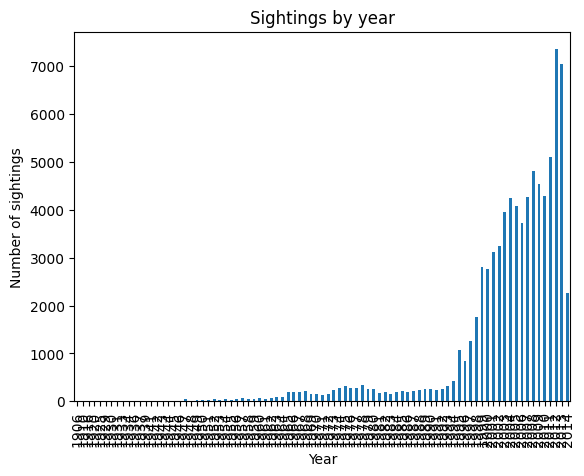

In [10]:
#the plot
year_counts.plot(kind='bar', title= "Sightings by year")

#labels
plt.xlabel('Year')
plt.ylabel('Number of sightings')

In [11]:
#making a variable for the shapes
shape_count = df['shape'].value_counts()

<Axes: xlabel='shape'>

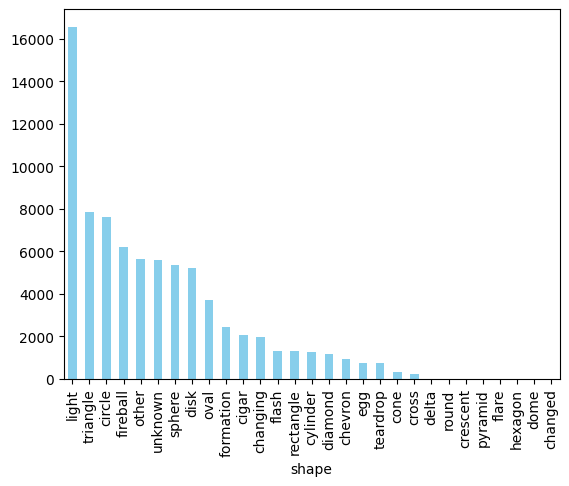

In [12]:
#plotting
shape_count.plot(kind='bar', color='skyblue')

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
        51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
        68, 69]),
 [Text(0, 0, '1933.0'),
  Text(1, 0, '1937.0'),
  Text(2, 0, '1943.0'),
  Text(3, 0, '1947.0'),
  Text(4, 0, '1948.0'),
  Text(5, 0, '1949.0'),
  Text(6, 0, '1950.0'),
  Text(7, 0, '1952.0'),
  Text(8, 0, '1953.0'),
  Text(9, 0, '1954.0'),
  Text(10, 0, '1955.0'),
  Text(11, 0, '1956.0'),
  Text(12, 0, '1957.0'),
  Text(13, 0, '1958.0'),
  Text(14, 0, '1959.0'),
  Text(15, 0, '1960.0'),
  Text(16, 0, '1961.0'),
  Text(17, 0, '1962.0'),
  Text(18, 0, '1963.0'),
  Text(19, 0, '1964.0'),
  Text(20, 0, '1965.0'),
  Text(21, 0, '1966.0'),
  Text(22, 0, '1967.0'),
  Text(23, 0, '1968.0'),
  Text(24, 0, '1969.0'),
  Text(25, 0, '1970.0'),
  Text(26, 0, '1971.0'),
  Text(27, 0,

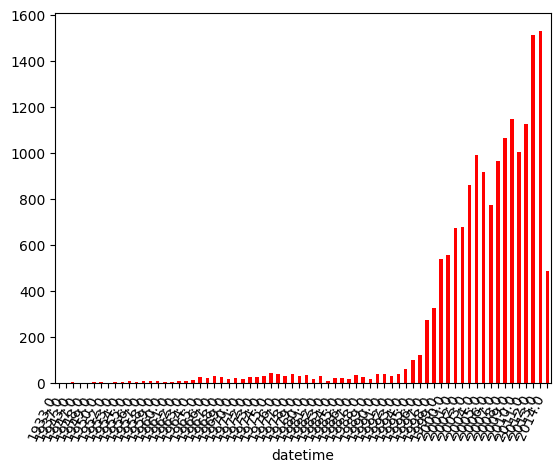

In [24]:
light_by_year = df[df['shape'] == 'light']


yearly_count_light = df.groupby(light_by_year['datetime'].dt.year).size()


yearly_count_light.plot(kind='bar', color='red')

plt.xticks(rotation=65, ha="right")

<Axes: xlabel='datetime'>

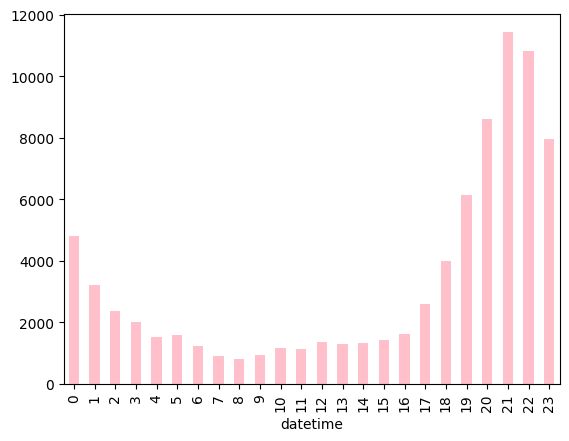

In [14]:
#hourly count
hourly_counts = df.groupby(df["datetime"].dt.hour).size()

hourly_counts.plot(kind='bar', color = "pink")

In [15]:
non_light = len(df[df['shape'] != 'light'])
light_total = len(df[df['shape'] == 'light'])

labels=['Non light base uaps', "light based UAPs"]

counts = [f"{non_light}", f"{light_total}"]

In [16]:
non_light

63767

In [17]:
light_total

16565

In [18]:
counts

['63767', '16565']

([<matplotlib.patches.Wedge at 0x199cb9ff760>,
 [Text(-0.32376020032904723, -1.051275098479411, 'Non light base uaps'),
  Text(0.3237602003290474, 1.051275098479411, 'light based UAPs')],
 [Text(-0.17659647290675304, -0.5734227809887695, '79.4%'),
  Text(0.1765964729067531, 0.5734227809887695, '20.6%')])

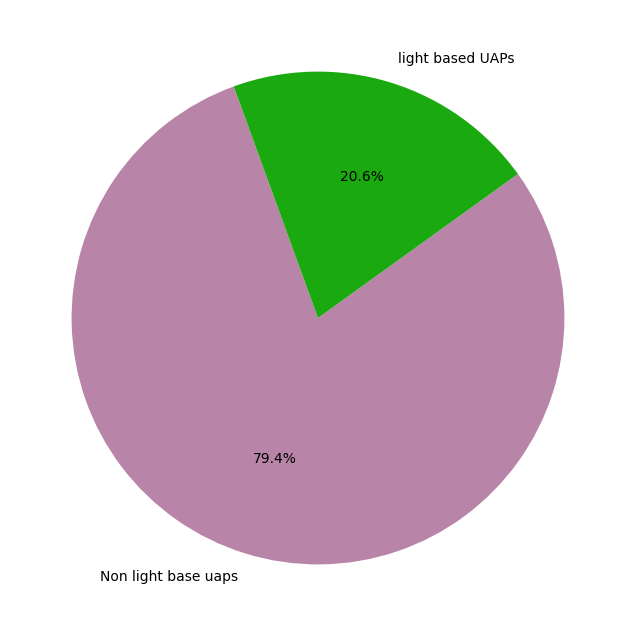

In [19]:
plt.figure(figsize=(8,8))

#lets make a pie chart
plt.pie(
    counts,
    labels=labels,
    startangle=110,
    colors=["#b884a8",'#1aaa10'],
    autopct="%1.1f%%")

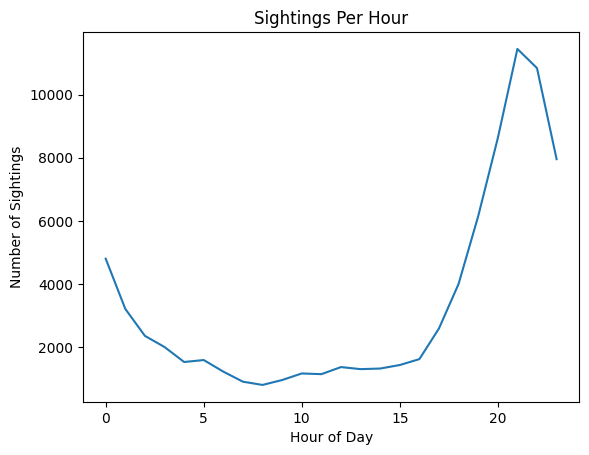

In [20]:
hourly_counts = df.groupby(df['datetime'].dt.hour).size().reindex(range(24), fill_value=0)
hourly_counts.plot(kind='line')
plt.xlabel("Hour of Day")
plt.ylabel("Number of Sightings")
plt.title("Sightings Per Hour")
plt.show()